# 05: options

`fxcarry.options` is three layers, and each one is unaware of the layer above it.
`PricingModel` values an option and inverts a quoted delta into the strike it refers to;
`Black76` is the only class in this notebook that knows what a Black-Scholes formula looks
like. `Instrument` says what is owned: a forward, a vanilla option, or any signed combination
of the two, and it prices and pays off without asking which pricing model produced its
numbers. `Overlay` sits one layer higher still: it states a rule in deltas, since deltas are
what a desk actually quotes, and only calls into `Instrument` once a market carrying a smile
tells it what strike a delta means today. Nothing above `PricingModel` names a formula, so
swapping `Black76` for another model would move every number in this notebook and touch no
line above it.

The previous notebook built `VolSurface` and `Smile`; this one prices off exactly what that
notebook produced. The next notebook puts these overlays on the sorted carry book itself.

In [1]:
import pathlib
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore", category=FutureWarning)

# nbconvert runs with this notebook's folder as the working directory, so walk up
# rather than assume how deep the notebook sits.
ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
            if (p / "data" / "raw").is_dir())
DATA = ROOT / "data" / "raw"
TAU = 1.0 / 12.0

## Black-76, priced on the forward

`Black76` values a European option with

$$V = \Omega\,\text{disc}\,\big(F\,N(\Omega d_1) - K\,N(\Omega d_2)\big), \qquad
d_1 = \frac{\ln(F/K) + \tfrac12\sigma^2\tau}{\sigma\sqrt{\tau}}, \qquad
d_2 = d_1 - \sigma\sqrt{\tau}$$

with $\Omega = +1$ for a call and $-1$ for a put. An FX option has two interest rates behind
it, one for each currency in the pair, and writing the model on spot would need both of them
separately. Writing it on the outright forward instead sidesteps that: covered parity
(notebook 03) already prices the rate differential into $F$ itself, so the two rates collapse
into the single quantity the formula actually needs. Only one discount factor is left,
`disc`, the domestic one that brings a payoff at expiry back to a value today.

In [2]:
from fxcarry import Black76

model = Black76()
F, K, vol = 0.0069, 0.0070, 0.10
print(f"call {model.value('call', F, K, vol, TAU):.8f}")
print(f"put  {model.value('put', F, K, vol, TAU):.8f}")

call 0.00003978
put  0.00013978


## Three checks: parity, the zero-vol floor, and a missing input

A pricing formula earns trust from what it does at its edges, not from one plausible number in
the middle. Put-call parity has to hold at any volatility, because it follows from a static
replication argument rather than from the option formula itself. Sending volatility to zero has
to collapse the option to its discounted intrinsic value, since an option nobody expects to
move should cost exactly what it already pays out. And a missing volatility has to stay
missing: turning a `NaN` into a price would let a gap in a volatility history read as a real,
tradable value.

In [3]:
call = model.value("call", F, K, vol, TAU)
put = model.value("put", F, K, vol, TAU)
parity = abs((call - put) - (F - K))
assert parity < 1e-12, "put call parity fails"

floor = model.value("call", F, K, 1e-12, TAU)
assert abs(floor - max(F - K, 0.0)) < 1e-12, "zero vol is not intrinsic"

missing = model.value("call", F, K, np.nan, TAU)
assert np.isnan(missing), "a missing vol priced to a number"

print(f"call minus put equals F minus K to {parity:.1e}")
print(f"vol to zero gives discounted intrinsic: {floor:.1e}")
print("a missing volatility stays missing, so a gap cannot read as a free option")

call minus put equals F minus K to 8.7e-19
vol to zero gives discounted intrinsic: 0.0e+00
a missing volatility stays missing, so a gap cannot read as a free option


## A delta is a coordinate, not a moneyness

`strike_from_delta` inverts a quoted delta into the strike it points at, and `atm_strike` is
the special case where a straddle's two legs net to zero delta. Both take volatility as an
argument rather than deriving one, so a given delta only maps to a strike once a volatility has
been chosen: feed the same delta a different volatility and a different strike comes back.

In [4]:
k25 = model.strike_from_delta(0.25, "put", F, vol, TAU)
back = model.delta("put", F, k25, vol, TAU)
assert abs(back + 0.25) < 1e-10, "strike_from_delta does not invert delta"
print(f"25 delta put strike {k25:.8f}, and its delta is {back:+.6f}")
print(f"at the money strike {model.atm_strike(F, vol, TAU):.8f}, above the forward "
      f"{F:.8f} by the variance term")

25 delta put strike 0.00676977, and its delta is -0.250000
at the money strike 0.00690288, above the forward 0.00690000 by the variance term


## A documented limitation: no premium-adjusted inverse

`Black76.delta` returns the plain spot delta, $\Omega\,e^{-r_b\tau}N(\Omega d_1)$, and
`strike_from_delta` inverts exactly that formula. FX desks actually quote delta four ways: spot
or forward, premium-adjusted or not, because paying the premium in the foreign currency
shifts the hedge ratio by the premium itself. The premium-adjusted version has no closed-form
inverse; recovering a strike from it needs a numerical solve, and `fxcarry` does not implement
one. Every delta in this library, including every `Vanilla.from_delta` call in the rest of
this notebook, is therefore the plain spot delta. That is a stated boundary of the pricing
layer, not a defect in it.

## Vectorization: the same call across a panel

Everything above priced one option at one date. `PricingModel.value` and its neighbors run on
numpy underneath, so feeding a `DataFrame` in place of a float prices every currency on every
date in one call, no loop involved. The panel below reuses the forward curve from notebook 03
and the smile from notebook 04, both read from `data/raw` again rather than carried in from
either notebook's own run. Reading the 1M, 10/25-delta vol surface means scanning
`fx_vol_daily.parquet` end to end before any filter applies, on the order of sixteen million
rows and, on this machine, ten seconds to half a minute depending on the disk cache; the cell
below times it rather than asking that to be taken on faith.

In [5]:
import time

import pyarrow.parquet as pq

from fxcarry import Catalog, MarketState, ParquetSource, SpotForward, VolSurface

catalog = Catalog.default()
source = ParquetSource(DATA / "spot_daily.parquet", DATA / "fwd_points_1m_daily.parquet")
curves = SpotForward.from_quotes(source.quotes(catalog.label_map("spot"), freq="M"),
                                 source.quotes(catalog.label_map("forward", "1M"), freq="M"),
                                 catalog, TAU)

# The brief's cell builds the surface without timing it. Notebook 04 established that this
# is a 16 million row parquet scan taking tens of seconds, and the house rule is that every
# number stated in prose has to be printed by a cell in this notebook, so the row count and
# a wall-clock timer are added here rather than repeating that claim on faith.
raw_rows = pq.ParquetFile(DATA / "fx_vol_daily.parquet").metadata.num_rows
t0 = time.time()
surface = VolSurface.from_source(ParquetSource(DATA / "fx_vol_daily.parquet"), catalog,
                                 tenors=["1M"], deltas=[10, 25])
elapsed = time.time() - t0
print(f"{raw_rows:,} rows read and decoded, then filtered to 1M, 10/25 delta, "
      f"in {elapsed:.1f} seconds")

smile = surface.panel_smile("1M", freq="M").reindex_like(curves.forward.mid)
market = MarketState(forward=curves.forward.mid, tenor=TAU, smile=smile)
print(type(market.model).__name__, "is the default model")

16,040,556 rows read and decoded, then filtered to 1M, 10/25 delta, in 19.4 seconds


Black76 is the default model


## `Instrument`: signed quantities and sums

`Instrument` overloads multiplication, negation and addition, so `-1.0 * put25 + 1.0 * put10`
builds a `Combination` the same way an ordinary formula would be written, and every leg still
prices and pays off on its own. A `Combination` is not a special case of a spread; a spread is
a `Combination` with two legs, a naked sale is a `Combination` with one, and both go through
the same `price` and `payoff`. The market above carries a whole panel, so pricing this
structure returns a full `DataFrame`, one row per month and one column per currency, rather
than a single number.

In [6]:
from fxcarry import Vanilla

put25 = Vanilla.from_delta(25, "put", market)
put10 = Vanilla.from_delta(10, "put", market)
structure = -1.0 * put25 + 1.0 * put10
priced = structure.price(market)
print("legs:", [(q, type(leg).__name__) for q, leg in structure.legs])
print("net price shape:", priced.shape)
print("net price, latest row:")
print(priced.iloc[-1].dropna().round(6).head(4))

legs: [(-1.0, 'Vanilla'), (1.0, 'Vanilla')]
net price shape: (513, 23)
net price, latest row:
AUD   -0.001458
CAD   -0.000883
CHF   -0.002368
CZK   -0.000081
Name: 2026-07-31 00:00:00, dtype: float64


## Payoff and worst case, on a grid

`payoff` is the value at expiry, computed directly rather than through the pricing model,
since a settled option needs no volatility. `worst_case` sweeps a grid of terminal rates and
reports the smallest payoff found on it. For a structure whose loss is bounded, the grid only
needs to be wide enough to reach the flat part of the payoff, and that width is a property of
the structure being priced, not of `worst_case` itself.

25 delta put: vol 0.0970, strike 0.00677356
10 delta put: vol 0.0950, strike 0.00666421
premium taken in: +0.00002017
worst case on the grid: -0.00010935
strike gap, the bound the loss cannot cross: -0.00010935, matched to 0.0e+00


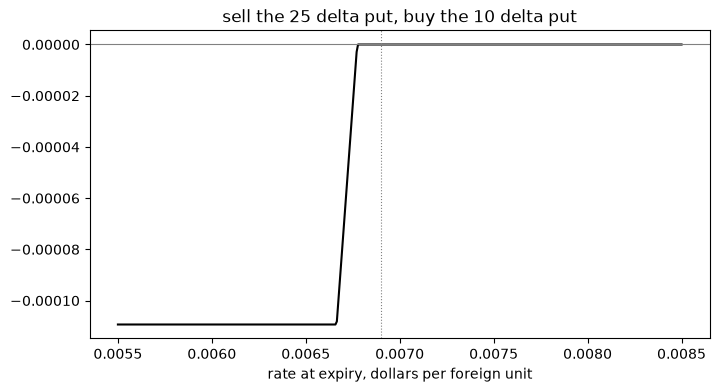

In [7]:
from fxcarry import Smile, VerticalSpread

grid = np.linspace(0.0055, 0.0085, 400)
scalar_market = MarketState(forward=0.0069, tenor=TAU,
                            smile=Smile(atm=0.10, risk_reversal={25: 0.01, 10: 0.02},
                                        butterfly={25: 0.002, 10: 0.005}))
combo = VerticalSpread(25, 10, "put").build(scalar_market)

_, sold = combo.legs[0]
_, bought = combo.legs[1]
K25, K10 = sold.strike, bought.strike
bound = -(K25 - K10)
print(f"25 delta put: vol {sold.vol:.4f}, strike {K25:.8f}")
print(f"10 delta put: vol {bought.vol:.4f}, strike {K10:.8f}")
print(f"premium taken in: {-combo.price(scalar_market):+.8f}")
print(f"worst case on the grid: {combo.worst_case(grid):+.8f}")
print(f"strike gap, the bound the loss cannot cross: {bound:+.8f}, "
      f"matched to {abs(combo.worst_case(grid) - bound):.1e}")

# Every plotting cell in this series ends with plt.show(); the brief's version of this cell
# does not call it, so it is added here, after the prints rather than before them so the
# figure is still the last thing the cell produces.
ax = pd.Series(combo.payoff(grid), index=grid).plot(figsize=(8, 4), color="black")
ax.axhline(0.0, color="grey", linewidth=0.8)
ax.axvline(0.0069, color="grey", linewidth=0.8, linestyle=":")
ax.set_title("sell the 25 delta put, buy the 10 delta put")
ax.set_xlabel("rate at expiry, dollars per foreign unit")
plt.show()

## `Overlay` and `.on(kind)`

An `Overlay` states a rule in deltas and knows nothing about which side of a book it will end
up protecting. `.on(kind)` returns the same rule rewritten against the other side of the
smile. Whether a hedge belongs on the call side or the put side depends on which direction the
position being protected is exposed to, not on anything the rule itself carries, so the same
`VerticalSpread` gets asked for either side depending on what it is covering.

In [8]:
from fxcarry import NoOverlay, SingleWing, VerticalSpread

rule = VerticalSpread(25, 10, "put")
print(rule, "\n", rule.on("call"))
print(SingleWing(25, "put", quantity=-1.0).build(scalar_market).legs[0][0], "= sold")
print("nothing on top:", NoOverlay().build(scalar_market).legs)

VerticalSpread(sell_delta=25, buy_delta=10, kind='put', quantities=(-1.0, 1.0)) 
 VerticalSpread(sell_delta=25, buy_delta=10, kind='call', quantities=(-1.0, 1.0))
-1.0 = sold
nothing on top: ()


## Check yourself

**What disappears from the pricing formula when it is written on the forward?** Both
currencies' interest rates as separate terms. An FX pair carries one rate on each side, but
covered parity already folds their difference into the outright forward, so `Black76`'s
formula only ever needs the single discount factor that brings a payoff back to a value today.
Neither rate appears in the option formula on its own.

**Why does the 25 delta strike move when the smile moves?** Because `strike_from_delta` takes
volatility as an input rather than assuming one. The delta section above priced the 25 delta
put at a flat 10% volatility and got a strike of 0.00676977. The payoff section's smile carries
a wing volatility of 9.7% at the same 25 delta instead, read off an at-the-money level, a risk
reversal and a butterfly rather than a flat guess, and the strike it implies moves to
0.00677356. Same delta, different volatility fed in, different strike out.

**What does `worst_case` report for an unbounded structure?** The worst payoff actually sampled
on the grid it was given, not a true floor. The vertical spread built above is bounded by
construction, both legs on the same wing pointing the same direction, so its worst point sits
at a fixed level that any sufficiently wide grid reaches, which the residual printed above
confirms to floating-point precision. A naked position like the single wing built for the
overlay section has no second leg to cap it, so its true worst case is unbounded; `worst_case`
still returns a number for it, but that number is only as bad as the grid's own edge, and a
wider grid would return a worse one.